# LSTM vs Transformer Comparison

In order to make it fair, I trained both the LSTM and Transformer on the hourly resampled jena datset with 72 input hours and 12 output hours. Both are trained on the same data split, and are now tested.

*All the code you see below was yanked from my lstm and transformer files, stripped of all comments and training bits.*

In [21]:
JENA_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

In [23]:
# When I was testing, it was useful to set the seed to know which hyperparams actually work.
SEED = 67 # - six seven :)
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('On device:', device)

On device: cuda


In [24]:
data = pd.read_csv(JENA_URL, compression='zip')
# Since the date/time column was already there, I just modified rather than dropping and creating another.
# The date format kept throwing errors coz pandas is very imperial
data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')
data = data.set_index('Date Time').sort_index()

<Axes: xlabel='Date Time'>

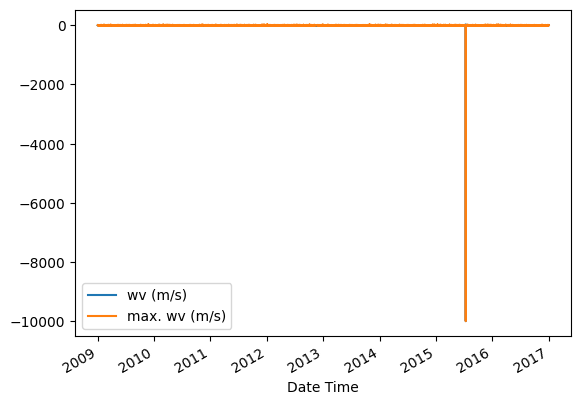

In [25]:
data.plot(y=['wv (m/s)', 'max. wv (m/s)'])

<Axes: xlabel='Date Time'>

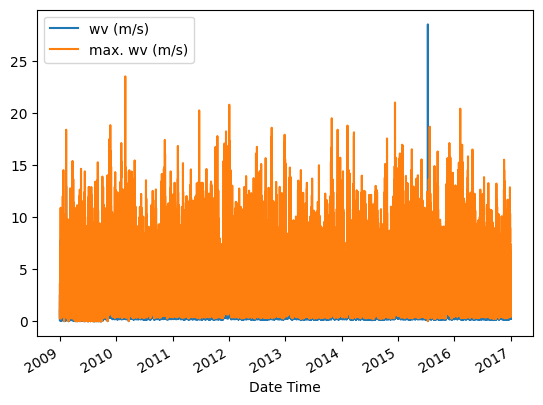

In [26]:
data.loc[data['wv (m/s)'] < -1, 'wv (m/s)'] = 0.0
data.loc[data['max. wv (m/s)'] < -1, 'max. wv (m/s)'] = 0.0
data.plot(y=['wv (m/s)', 'max. wv (m/s)'])

In [27]:
wv = data.pop("wv (m/s)")
max_wv = data.pop("max. wv (m/s)")
wd_rad = data.pop("wd (deg)") * np.pi / 180.0

data['wx'] = wv * np.cos(wd_rad)
data['wy'] = wv * np.sin(wd_rad)
data['max wx'] = max_wv * np.cos(wd_rad)
data['max wy'] = max_wv * np.sin(wd_rad)

data.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wx,wy,max wx,max wy
Date Time,,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,-0.911955,0.478787,-1.549439,0.813474
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,-0.518797,0.499249,-1.080827,1.040103
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,-0.187962,0.027756,-0.623242,0.092032
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,-0.323359,-0.105066,-0.475528,-0.154508
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,-0.264351,-0.180328,-0.520442,-0.355021


In [28]:
data = data.resample('1h').mean()
data = data.interpolate(limit_direction='both')
print(data.shape)
data.head()

(70129, 15)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wx,wy,max wx,max wy
Date Time,,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,-0.441285,0.144080,-0.849895,0.287216
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,-0.297470,0.007457,-0.660594,0.035147
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,-0.216609,-0.025517,-0.477351,-0.095330
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,-0.140886,0.064960,-0.454137,0.194917
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,-0.101078,0.178436,-0.258605,0.340065


In [29]:
seconds = data.index.map(pd.Timestamp.timestamp)
seconds_in_day = 24 * 60 * 60
seconds_in_year = 365 * seconds_in_day

data['sin_of_day'] = np.sin(seconds * 2 * np.pi / seconds_in_day)
data['cos_of_day'] = np.cos(seconds * 2 * np.pi / seconds_in_day)
data['sin_of_year'] = np.sin(seconds * 2 * np.pi / seconds_in_year)
data['cos_of_year'] = np.cos(seconds * 2 * np.pi / seconds_in_year)

target_name = 'T (degC)'
columns = list(data.columns)
print(f"{len(columns)} columns and target is '{target_name}'")

19 columns and target is 'T (degC)'


In [30]:
n = len(data)
train_data = data.iloc[: int(n * 0.7)]
val_data = data.iloc[int(n * 0.7) : int(n * 0.85)]
test_data = data.iloc[int(n * 0.85) :]

print(f"No. of train: {len(train_data)} / val: {len(val_data)} / test: {len(test_data)}")

No. of train: 49090 / val: 10519 / test: 10520


In [31]:
mean = train_data[columns].mean()
std = train_data[columns].std()

train_data = (train_data[columns] - mean) / std
val_data = (val_data[columns] - mean) / std
test_data = (test_data[columns] - mean) / std

target_index = columns.index(target_name)
target_mean = mean.iloc[target_index]
target_std = std.iloc[target_index]

In [32]:
def sequence(inp_data):
  np_data = inp_data.values.astype(np.float32)
  max_sequences = len(np_data) - 72 - 12 + 1 # plus 1 coz indices start at 0
  X = np.zeros((max_sequences, 72, np_data.shape[1]), dtype=np.float32) # x has sequences, 72 of them, each having features
  y = np.zeros((max_sequences, 12), dtype=np.float32)

  for i in range(max_sequences):
    X[i] = np_data[i : i + 72]
    y[i] = np_data[i + 72 : i + 72 + 12, target_index]

  return X, y

In [33]:
X_train, y_train = sequence(train_data)
X_test, y_test = sequence(test_data)
X_val, y_val = sequence(val_data)

In [34]:
class WeatherSequenceDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.from_numpy(X) # Since I converted to numpy in the sequence function
    self.y = torch.from_numpy(y)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.y[index]

In [35]:
batch_size = 256 # changed from 128

train_loader = DataLoader(
    WeatherSequenceDataset(X_train, y_train), batch_size, shuffle=True, drop_last=True
)

val_loader = DataLoader(
    WeatherSequenceDataset(X_val, y_val), batch_size, shuffle=False
)

test_loader = DataLoader(
    WeatherSequenceDataset(X_test, y_test), batch_size, shuffle=False
)

In [36]:
class lstm_unit(nn.Module):
  def __init__(self, input_size, hidden_size):
    super().__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size

    # I'm using parameters coz it's easier to initialize the weights custom-ly
    self.weight_x = nn.Parameter(torch.empty(4 * hidden_size, input_size))
    self.weight_h = nn.Parameter(torch.empty(4 * hidden_size, hidden_size))
    self.bias_x = nn.Parameter(torch.empty(4 * hidden_size))
    self.bias_h = nn.Parameter(torch.empty(4 * hidden_size))

    self.reset_parameters()

  def reset_parameters(self):
    # I saw that this was the best way to init weights
    standard_variation = 1.0 / math.sqrt(self.hidden_size)
    for weight in self.parameters():
        nn.init.uniform_(weight, -standard_variation, standard_variation)

  def forward(self, x, prev_states):
    h_t, c_t = prev_states

    gates = (x @ self.weight_x.T + self.bias_x) + (h_t @ self.weight_h.T + self.bias_h)
    i_gate, f_gate, c_gate, o_gate = gates.chunk(4, dim=1)

    i = torch.sigmoid(i_gate)
    f = torch.sigmoid(f_gate)
    c = torch.tanh(c_gate)
    o = torch.sigmoid(o_gate)

    c_x = f * c_t + i * c
    h_x = o * torch.tanh(c_x)

    return h_x, c_x

# Hidden size is 128 and 2 layers, with dropout here and there
class JenaLSTM(nn.Module):
  def __init__(self, hidden_size, layered):
    super().__init__()

    self.hidden_size = hidden_size
    self.layered = layered

    self.lstm_1 = lstm_unit(
        len(columns),
        self.hidden_size
    )
    if layered:
      self.lstm_2 = lstm_unit(
          self.hidden_size,
          self.hidden_size
      )

    self.drop = nn.Dropout(0.3) # og is 0.2: debug

    self.head = nn.Sequential(
        self.drop,
        nn.Linear(self.hidden_size, 12)
    )

  def forward(self, x):
    batch_size, seq_len, _ = x.size()
    device = x.device

    h_t_1 = torch.zeros(batch_size, self.hidden_size, device=device)
    c_t_1 = torch.zeros(batch_size, self.hidden_size, device=device)

    if self.layered:
      h_t_2 = torch.zeros(batch_size, self.hidden_size, device=device)
      c_t_2 = torch.zeros(batch_size, self.hidden_size, device=device)

    for t in range(seq_len):
      x_t = x[:, t, :]
      h_t_1, c_t_1 = self.lstm_1(x_t, (h_t_1, c_t_1))

      if self.layered:
        dropped = self.drop(h_t_1)
        h_t_2, c_t_2 = self.lstm_2(dropped, (h_t_2, c_t_2))

    if self.layered:
      out = self.head(h_t_2)
      return out
    else:
      out = self.head(h_t_1)
      return out


In [37]:
inp = 72
cast = 12

In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len=inp):
    super().__init__()

    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
    evens = torch.arange(0, d_model // 2).float() * 2.0
    div_term = 10_000.0 ** (evens / d_model)

    pe[:, 0::2] = torch.sin(pos * div_term) # the even indices become sin
    pe[:, 1::2] = torch.cos(pos * div_term) # the odd ones are cos

    pe = pe.unsqueeze(0) # adding an extra dimension for the batches
    # I've done this so that it doesn't get backpropped
    self.register_buffer('pe', pe)

  def forward(self, x):
    return x + self.pe[:, :x.size(1), :]

class JenaTransformer(nn.Module):
  def __init__(self, d_model, nhead, num_layers):
    super().__init__()

    self.d_model = d_model

    self.project = nn.Linear(len(columns), self.d_model)
    self.pos_enc = PositionalEncoding(self.d_model, max_len=inp)

    encoder_layer = nn.TransformerEncoderLayer(
        d_model=self.d_model,
        nhead=nhead,
        dim_feedforward=256,
        dropout=0.2,
        batch_first=True
    )
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    self.drop = nn.Dropout(0.2)

    self.head = nn.Sequential(
        self.drop,
        nn.Linear(self.d_model, cast)
    )

  def forward(self, x):
    x = self.project(x)
    x = self.pos_enc(x)

    out = self.encoder(x)

    last = out[:, -1, :]
    return self.head(last)

In [39]:
def evaluate(model, loader):
  predictions = []
  actuals = []

  model.eval()
  with torch.no_grad():
    for xt, yt in loader:
      xt, yt = xt.to(device), yt.to(device)

      y_ = model(xt)

      predictions.append(y_.cpu().numpy())
      actuals.append(yt.cpu().numpy())

  # Concatenate becoz we load it in batches
  predictions = np.concatenate(predictions)
  actuals = np.concatenate(actuals)
  return predictions, actuals

All the bits of code above this were yanked from my other files, everything below shows comparison between the two.

In [ ]:
lstm = JenaLSTM(hidden_size=128, layered=False).to(device)
transformer = JenaTransformer(d_model=64, nhead=4, num_layers=3).to(device)

lstm_states = torch.load('saved_models/lstm.pt', weights_only=True)
transformer_states = torch.load('saved_models/transformer_72.pt', weights_only=True)
lstm.load_state_dict(lstm_states)
transformer.load_state_dict(transformer_states)

<All keys matched successfully>

In [41]:
predictions_lstm_raw, actuals_lstm_raw = evaluate(lstm, test_loader)
predictions_transformer_raw, actuals_transformer_raw = evaluate(transformer, test_loader)

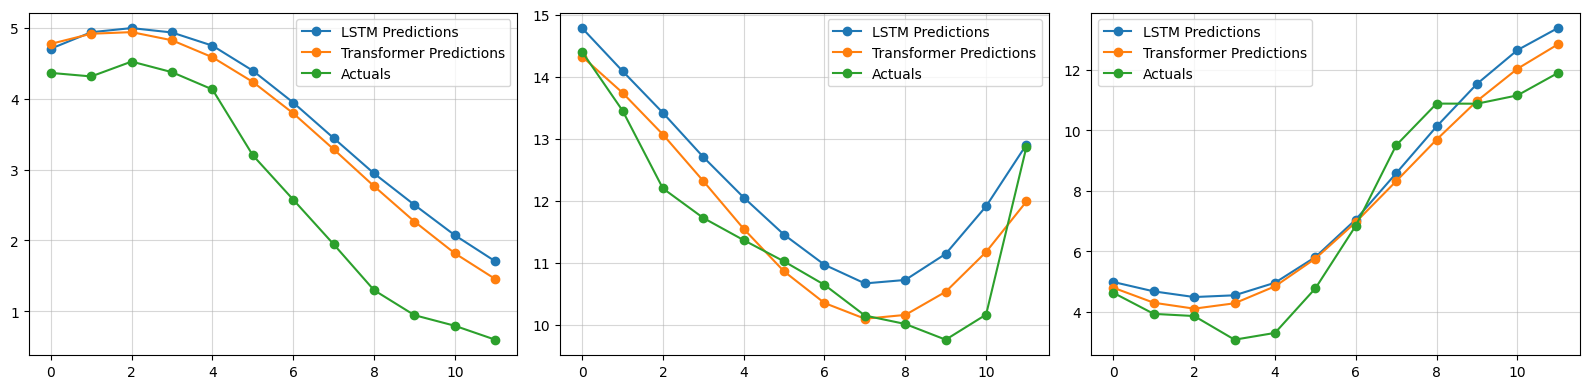

In [49]:
from random import randint

predictions_lstm = predictions_lstm_raw * target_std + target_mean
actuals_lstm = actuals_lstm_raw * target_std + target_mean

predictions_transformer = predictions_transformer_raw * target_std + target_mean
actuals_transformer = actuals_transformer_raw * target_std + target_mean

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax in axes:
    index = randint(0, len(predictions_lstm) - 1)

    ax.plot(predictions_lstm[index], label='LSTM Predictions', marker='o')
    ax.plot(predictions_transformer[index], label='Transformer Predictions', marker='o')
    ax.plot(actuals_lstm[index], label='Actuals', marker='o')
    ax.grid(alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()